In [32]:
# Data collection command:
# `python comet_download.py --project=ns-gradient-descent-hyper-search --n_threads=8`

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.analysis_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

## Load Data

In [34]:
save_path = 'figures/'
config_data_path = 'data/ns-gradient-descent-hyper-search_params.csv'
run_data_path = 'data/ns-gradient-descent-hyper-search_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
{k: len(v) for k, v in config_dfs.items()}

{'autostep_e2e': 385, 'autostep_and_sgd': 958}

In [35]:
print("_____Best Hyperparameter Configurations_____")
best_config_dfs, best_run_dfs = get_best_ablation_values(config_dfs, run_dfs)
{k: len(v) for k, v in best_config_dfs.items()}

_____Best Hyperparameter Configurations_____

=== autostep_e2e ===

Configuration: (no split vars)
  Best optimizer.learning_rate=${eval:2**4}
  Best optimizer.meta_learning_rate=${eval:2**-5}


=== autostep_and_sgd ===

Configuration: (no split vars)
  Best representation_optimizer.learning_rate=${eval:2**2}
  Best optimizer.learning_rate=${eval:2**-12}
  Best optimizer.meta_learning_rate=${eval:2**-7}



{'autostep_e2e': 5, 'autostep_and_sgd': 5}

## Comparison

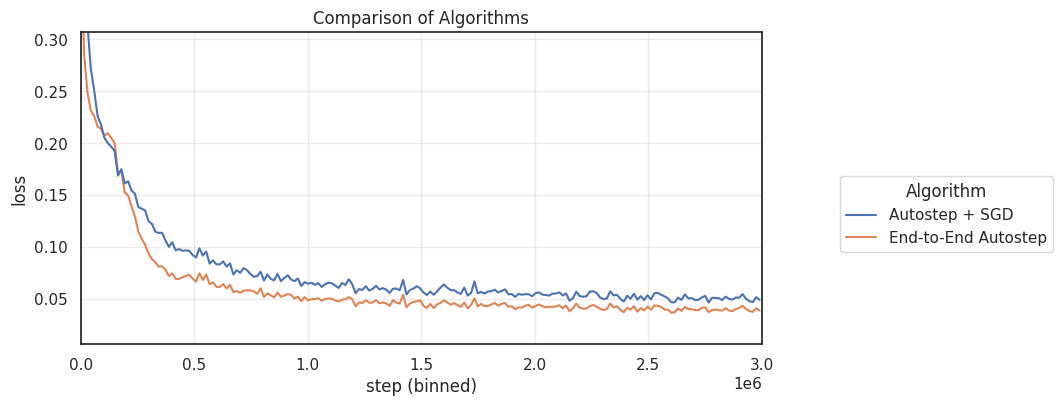

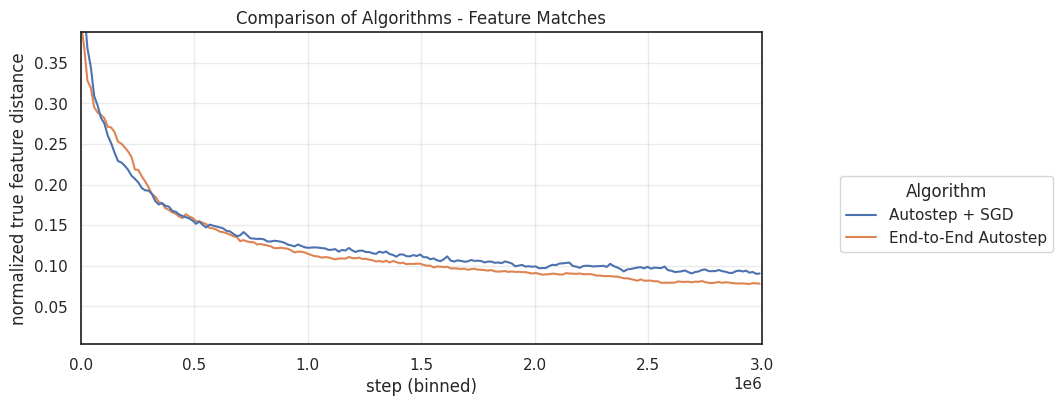

In [36]:
combined_run_df = pd.concat(list(best_run_dfs.values()))
combined_config_df = pd.concat(list(best_config_dfs.values()))

algo_map = {
    'autostep_e2e': 'End-to-End Autostep',
    'autostep_and_sgd': 'Autostep + SGD',
}
combined_config_df['algo'] = combined_config_df['sweep_name'].map(algo_map)

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.title('Comparison of Algorithms')
plt.show()

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/average_best_match_normalized_distance',
    y_label = 'normalized true feature distance',
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.title('Comparison of Algorithms - Feature Matches')
plt.show()

## End-to-End Autostep Hyperparameter Sensitivity

Text(0.5, 1.0, 'Autostep + Feature Search Feature Matches')

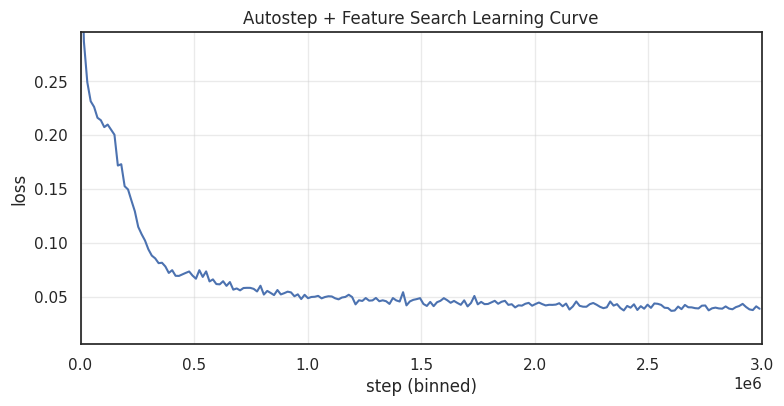

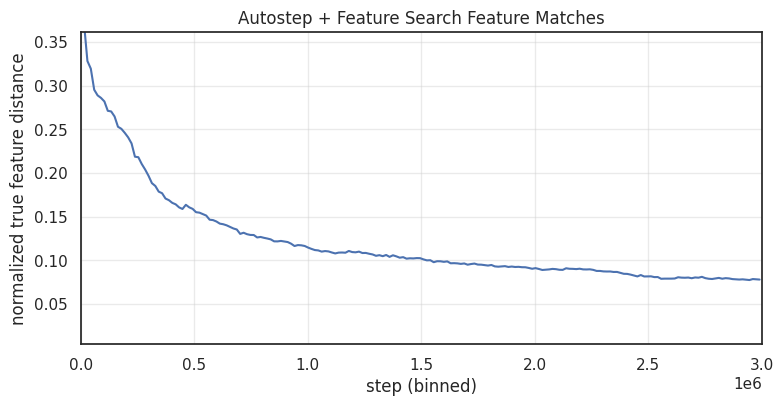

In [37]:
plot_learning_curves(
    run_df = best_run_dfs['autostep_e2e'],
    config_df = best_config_dfs['autostep_e2e'],
    n_bins = 200,
    figsize = (8, 4),
)
plt.title('Autostep + Feature Search Learning Curve')

plot_learning_curves(
    run_df = best_run_dfs['autostep_e2e'],
    config_df = best_config_dfs['autostep_e2e'],
    y_col = 'feature_match/average_best_match_normalized_distance',
    y_label = 'normalized true feature distance',
    n_bins = 200,
    figsize = (8, 4),
)
plt.axhline(20, color='black', linestyle='--')

plt.title('Autostep + Feature Search Feature Matches')

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


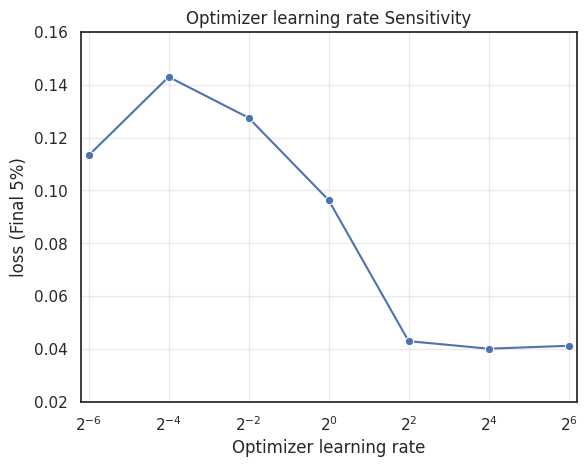

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


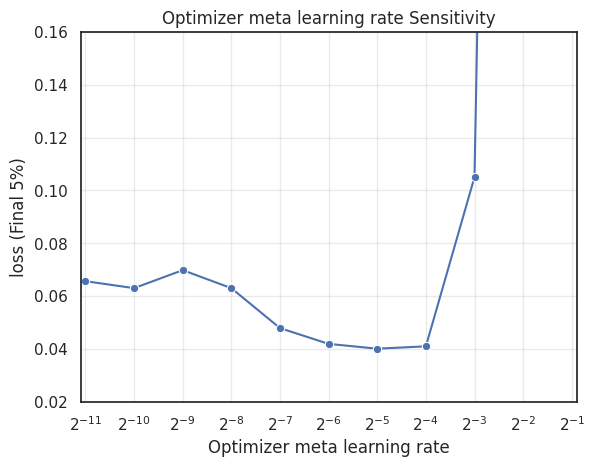

In [41]:
default_hyperparams = {
    'optimizer|learning_rate': 2**4,
    'optimizer|meta_learning_rate': 2**-5,
}

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = run_dfs['autostep_e2e'],
        config_df = config_dfs['autostep_e2e'],
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
    
    plot_param_sensitivity(
            run_df = selected_run_df,
            config_df = selected_config_df,
            x_col = param_name,
            title = f'{param_label} Sensitivity',
            x_label = param_label,
            y_label = 'loss',
            metric_col = 'loss',
            metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
            step_col = 'step',
            legend_title = None,
            show_ci = False,
            baseline_col = None,
            pow_2_x_axis = 'learning_rate' in param_name,
            pow_2_legend = True,
        )
    plt.ylim(0.02, 0.16)
    plt.show()

## Autostep + SGD Hyperparameter Sensitivity

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


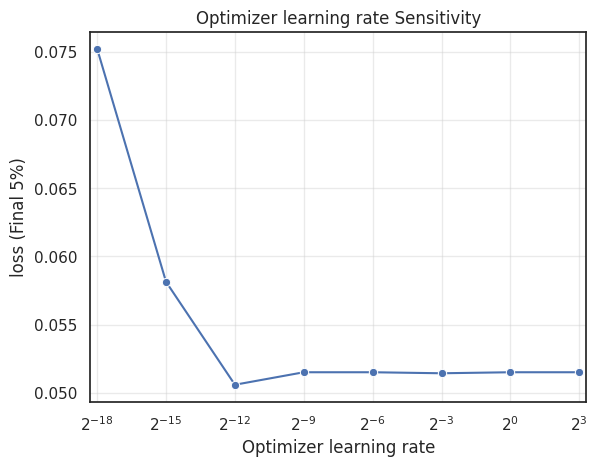

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


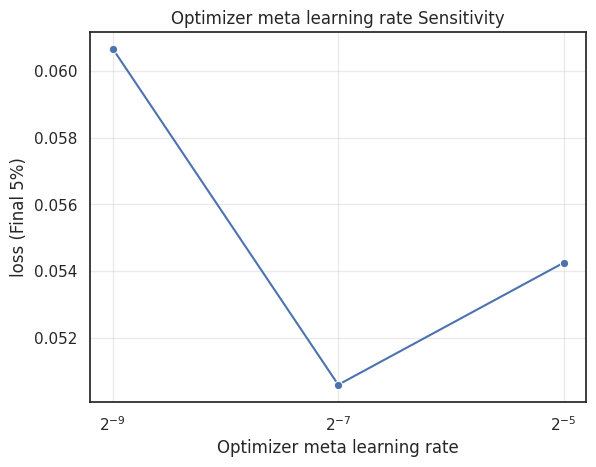

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


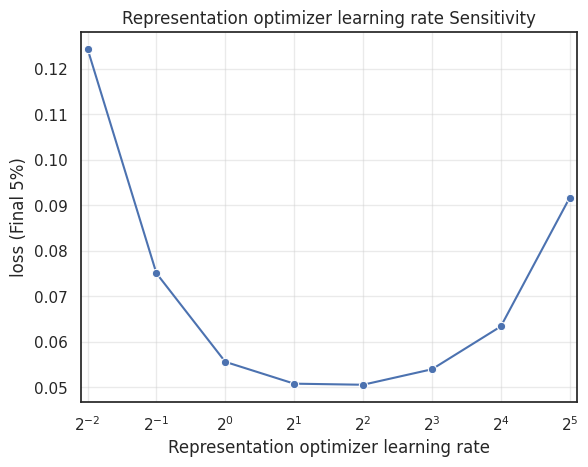

In [42]:
default_hyperparams = {
    'optimizer|learning_rate': 2**-12,
    'optimizer|meta_learning_rate': 2**-7,
    'representation_optimizer|learning_rate': 2**2
}

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = run_dfs['autostep_and_sgd'],
        config_df = config_dfs['autostep_and_sgd'],
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
    
    plot_param_sensitivity(
            run_df = selected_run_df,
            config_df = selected_config_df,
            x_col = param_name,
            title = f'{param_label} Sensitivity',
            x_label = param_label,
            y_label = 'loss',
            metric_col = 'loss',
            metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
            step_col = 'step',
            legend_title = None,
            show_ci = False,
            baseline_col = None,
            pow_2_x_axis = 'learning_rate' in param_name,
            pow_2_legend = True,
        )
    plt.show()